In [ ]:
## interp and fourier dependencies
from math import ceil
import numpy as np
from sigpy import backend, interp, util, fourier


%matplotlib inline
%load_ext autoreload
%autoreload 2

import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

import aymansigmri as asm

kspace = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coords = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp = kspace, coord=coords, n_missing=0, undersampling_factor=1)

In [2]:
def nufft_gridding(kspace, coords):
    n_coils = kspace.shape[0]
    n_samples = kspace.shape[-1]
    dcf = np.sqrt(coords[..., 0]**2 + coords[..., 1]**2)
    imagegrid = sp.nufft_adjoint(kspace * dcf, coords, oshape=(n_coils, n_samples, n_samples))
    gridded_data = sp.fft(imagegrid, axes=(-2, -1), norm='ortho')
    return gridded_data

- Having dcf div by 256 causes div in scale factor - unsure why toby advised to do this

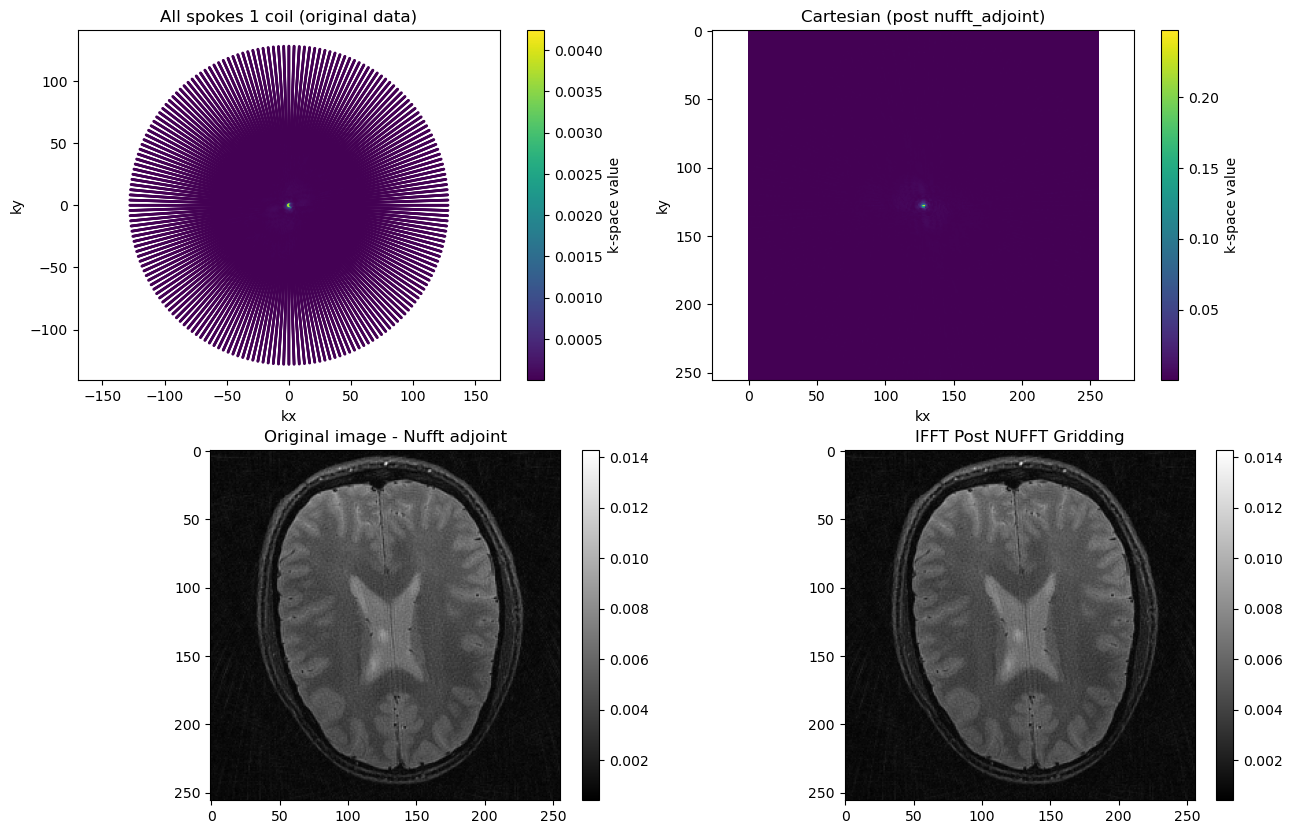

In [3]:
### Original Image
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_orig_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords, oshape=(12,256,256))
zte_orig_image = np.sum(np.abs(zte_orig_grid)**2, axis=0)**0.5


### Post gridding with nufft
zte_cart_kspace_imgtrip = nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)
im_cart_grid = sp.ifft(zte_cart_kspace_imgtrip,norm='ortho',oshape=(12,256,256))
im_rss_cart = np.sum(np.abs(im_cart_grid)**2, axis=0)**0.5

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = zte_radial_kspace[0].reshape(-1)


fig, ax = plt.subplots(2, 2, figsize=(15, 10))
im0 = ax[0, 0].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace), s=1)
ax[0, 0].set_title('All spokes 1 coil (original data)')
ax[0, 0].set_xlabel('kx')
ax[0, 0].set_ylabel('ky')
ax[0, 0].axis('equal')
fig.colorbar(im0, ax=ax[0,0], label='k-space value')

im1 = ax[0, 1].imshow(np.abs(zte_cart_kspace_imgtrip[0]))
ax[0, 1].set_title('Cartesian (post nufft_adjoint)')
ax[0, 1].set_xlabel('kx')
ax[0, 1].set_ylabel('ky')
ax[0, 1].axis('equal')
fig.colorbar(im1, ax=ax[0, 1], label='k-space value')

im0 = ax[1, 0].imshow(zte_orig_image, cmap='gray')
ax[1, 0].set_title('Original image - Nufft adjoint')
plt.colorbar(im0, ax=ax[1, 0], fraction=0.046, pad=0.04)

im1 = ax[1, 1].imshow(im_rss_cart, cmap='gray', )
ax[1, 1].set_title('IFFT Post NUFFT Gridding')
plt.colorbar(im1, ax=ax[1, 1], fraction=0.046, pad=0.04)

plt.show()

/var/folders/lp/mmccs9596xb7321q5q75xnj00000gn/T/ipykernel_38396/2204442327.py:20: RuntimeWarning: invalid value encountered in divide
  out[c] = np.where(np.abs(weights) > eps, g / weights, 0)


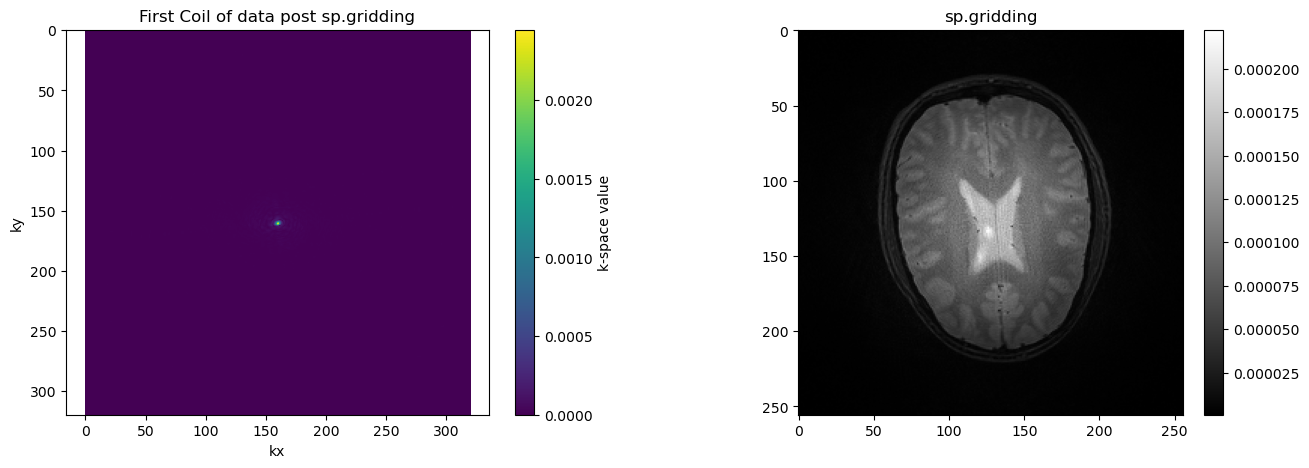

In [4]:
def gridding_operator(kspace_data, coord, N, width=4, oversamp=1.25):
    n_coils = kspace_data.shape[0]
    os_shape = (int(N * oversamp), int(N * oversamp))
    beta = np.pi * np.sqrt((width / oversamp) ** 2 * (oversamp - 0.5) ** 2 - 0.8)

    dcf = np.sqrt(coord[..., 0] ** 2 + coord[..., 1] ** 2)
    dcf = dcf / dcf.max()

    coord_os = coord * oversamp + np.array(os_shape) // 2

    # weight map: grid the DCF alone (same kernel, same coords)
    weights = sp.gridding(dcf.astype(complex), coord_os, os_shape,
                          kernel='kaiser_bessel', width=width, param=beta)

    out = np.zeros((n_coils, *os_shape), dtype=complex)
    eps = 1e-6 * np.abs(weights).max()
    for c in range(n_coils):
        g = sp.gridding(kspace_data[c] * dcf, coord_os, os_shape,
                        kernel='kaiser_bessel', width=width, param=beta)
        out[c] = np.where(np.abs(weights) > eps, g / weights, 0)
    return out


gridding_cartesian = gridding_operator(kspace_data = zte_radial_kspace, coord = zte_radial_coords, N=256)

gridding_image_grid = sp.ifft(gridding_cartesian,oshape=(12,256,256))

gridded_image = np.sum(np.abs(gridding_image_grid)**2, axis=0)**0.5

fig, ax = plt.subplots(1, 2, figsize=(15, 5))


im0 = ax[0].imshow(np.abs(gridding_cartesian[0]))
ax[0].set_title('First Coil of data post sp.gridding')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
fig.colorbar(im0, ax=ax[0], label='k-space value')

im1 = ax[1].imshow(gridded_image, cmap='gray')
ax[1].set_title('sp.gridding')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

## Stepping through `nufft_adjoint` to see scale changing

In [ ]:
def nufft_adjoint(input, coord, oshape=None, oversamp=1.25, width=4):
    ndim = coord.shape[-1]
    beta = np.pi * (((width / oversamp) * (oversamp - 0.5)) ** 2 - 0.8) ** 0.5
    if oshape is None:
        oshape = list(input.shape[: -coord.ndim + 1]) + fourier.estimate_shape(coord)
    else:
        oshape = list(oshape)

    os_shape = fourier._get_oversamp_shape(oshape, ndim, oversamp)

    # Gridding
    coord = fourier._scale_coord(coord, oshape, oversamp)
    output = interp.gridding(
        input, coord, os_shape, kernel="kaiser_bessel", width=width, param=beta
    )
    output /= width**ndim

    # IFFT
    output = fourier.ifft(output, axes=range(-ndim, 0), norm=None)

    # Crop
    output = util.resize(output, oshape)
    output *= util.prod(os_shape[-ndim:]) / util.prod(oshape[-ndim:]) ** 0.5

    # Apodize
    fourier._apodize(output, ndim, oversamp, width, beta)

    return output

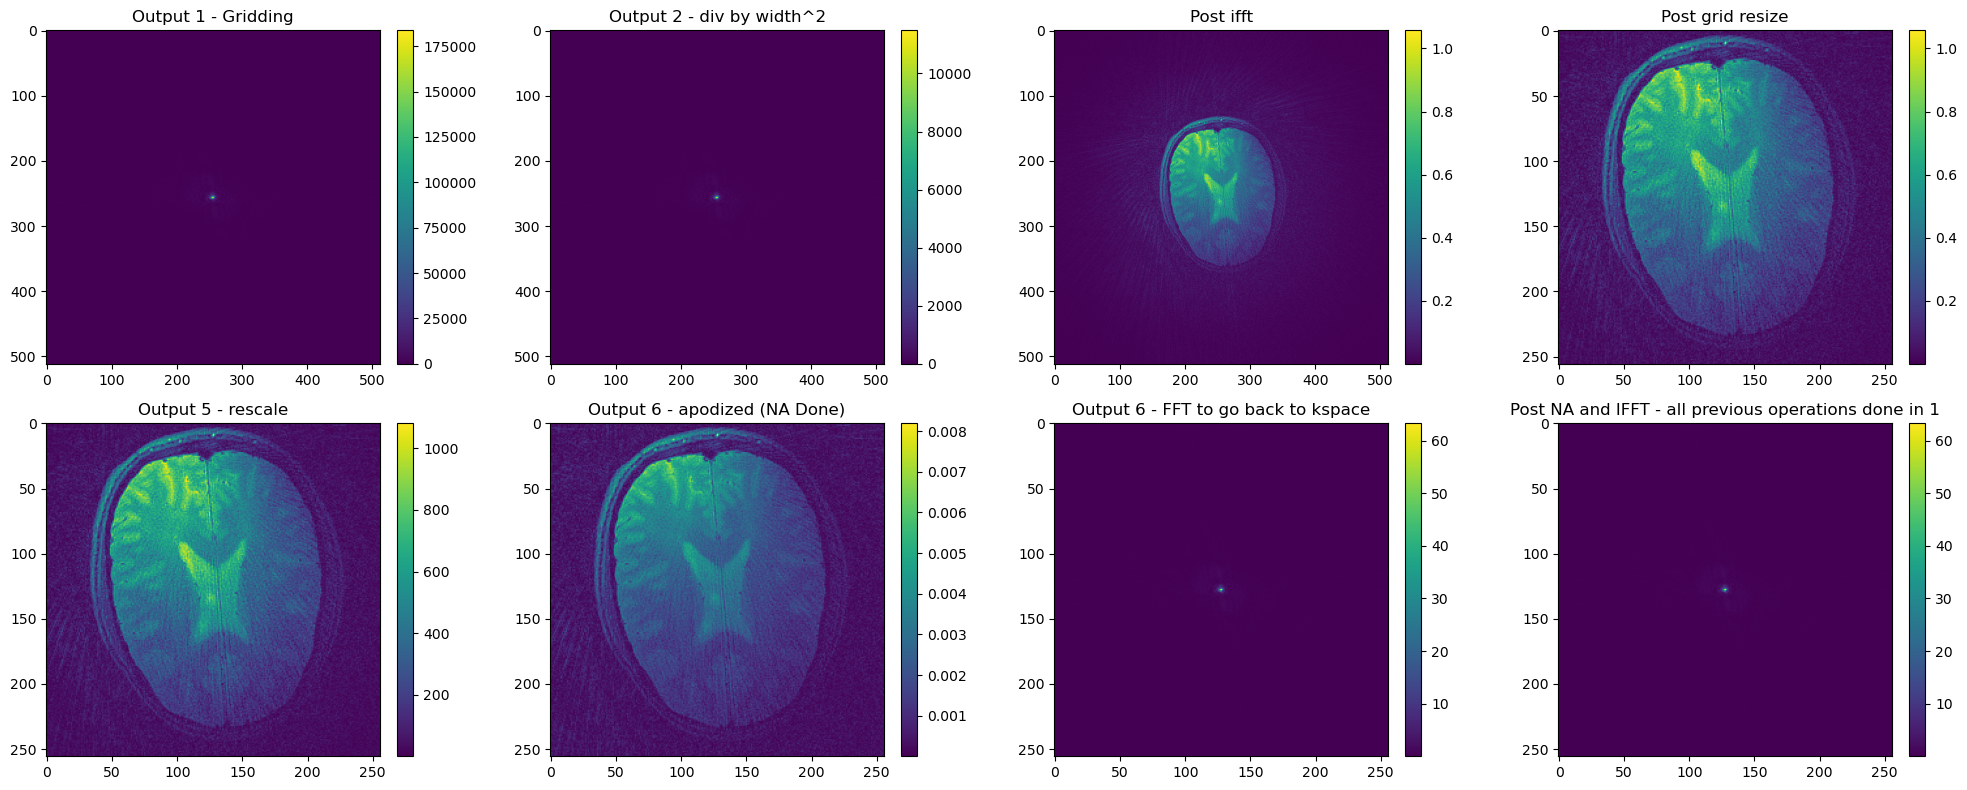

In [19]:
x = np.ones(shape=(192,256), dtype=complex)
x = zte_radial_kspace[0]

dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)



### Step through NUFFT Adjoint
width = 4
oversamp = 2
ndim = 2
oshape=(256,256)

beta = np.pi * (((width / oversamp) * (oversamp - 0.5)) ** 2 - 0.8) ** 0.5

os_shape = fourier._get_oversamp_shape(oshape, ndim = ndim, oversamp=oversamp)

coord = fourier._scale_coord(zte_radial_coords, oshape, oversamp=oversamp)

output1 = interp.gridding(x * dcf, coord, os_shape, kernel="kaiser_bessel", width=width, param=beta)
output2 = output1 / width**ndim
output3 = fourier.ifft(output2, axes=range(-ndim, 0), norm=None)
output4 = util.resize(output3, oshape)
output5 = output4 * util.prod(os_shape[-ndim:]) / util.prod(oshape[-ndim:]) ** 0.5

### NOTE: Final operation; apodize in place is above plot showing 'output 6'


### Post gridding with nufft a per expected pipeline
x_grid = sp.nufft_adjoint(x * dcf, zte_radial_coords, oshape=(256,256), oversamp=2)

x_cart = sp.fft(x_grid, oshape=(256, 256), norm=None)

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = x.reshape(-1)

x_gridding = sp.gridding(x, zte_radial_coords, shape=(256, 256), kernel='kaiser_bessel')

x_post = sp.nufft(x_cart, zte_radial_coords)

fig, ax = plt.subplots(2, 4, figsize=(20, 8))


# NUFFT adjoint image
im1 = ax[0, 0].imshow(np.abs(output1), cmap="viridis")
ax[0, 0].set_title("Output 1 - Gridding")
fig.colorbar(im1, ax=ax[0, 0], fraction=0.046, pad=0.04)

im2 = ax[0, 1].imshow(np.abs(output2), cmap="viridis")
ax[0, 1].set_title("Output 2 - div by width^2")
fig.colorbar(im2, ax=ax[0, 1], fraction=0.046, pad=0.04)

im3 = ax[0, 2].imshow(np.abs(output3), cmap="viridis")
ax[0, 2].set_title("Post ifft")
fig.colorbar(im3, ax=ax[0, 2], fraction=0.046, pad=0.04)

im_NA = ax[0, 3].imshow(np.abs(output4),cmap="viridis")
ax[0, 3].set_title("Post grid resize")
fig.colorbar(im_NA, ax=ax[0, 3], fraction=0.046, pad=0.04)

im4 = ax[1, 0].imshow(np.abs(output5), cmap="viridis")
ax[1, 0].set_title("Output 5 - rescale")
fig.colorbar(im4, ax=ax[1, 0], fraction=0.046, pad=0.04)

fourier._apodize(output5, ndim=ndim,oversamp=oversamp, width=width, beta=beta) ###NOTE: line needs to be here bc fur.apod operates in place

im5 = ax[1, 1].imshow(np.abs(output5), cmap="viridis")
ax[1, 1].set_title("Output 6 - apodized (NA Done)")
fig.colorbar(im5, ax=ax[1, 1], fraction=0.046, pad=0.04)
### NA is Done

output6 = sp.fft(output5,oshape=(256, 256), norm=None)


im5 = ax[1, 2].imshow(np.abs(output6), cmap="viridis")
ax[1, 2].set_title("Output 6 - FFT to go back to kspace")
fig.colorbar(im5, ax=ax[1, 2], fraction=0.046, pad=0.04)

im_NA = ax[1, 3].imshow(np.abs(x_cart), cmap="viridis")
ax[1, 3].set_title("Post NA and IFFT - all previous operations done in 1")
fig.colorbar(im_NA, ax=ax[1, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
dcf.max()
print(np.abs(output5).max(), np.abs(x_grid).max(), np.allclose(output5, x_grid))

0.008205541374019265 0.008205541374019265 True


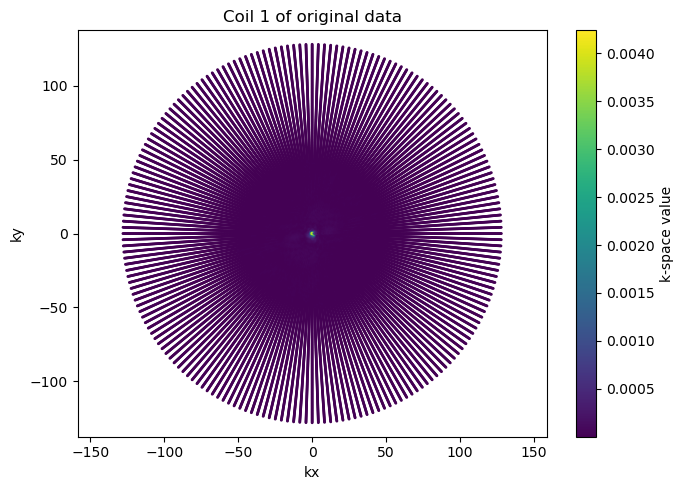

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))

im0 = ax.scatter(
    all_coords[:, 0],
    all_coords[:, 1],
    c=np.abs(all_kspace),
    s=1,
    cmap="viridis"
)

ax.set_title("Coil 1 of original data")
ax.set_xlabel("kx")
ax.set_ylabel("ky")
ax.axis("equal")

fig.colorbar(im0, ax=ax, label="k-space value")

plt.tight_layout()
plt.show()

## Stepping through `gridding` to see scale changing

In [5]:
def gridding(input, coord, shape, kernel="kaiser-bessel", width=2, param=1):
    ndim = coord.shape[-1]

    batch_shape = shape[:-ndim]
    batch_size = util.prod(batch_shape)

    pts_shape = coord.shape[:-1]
    npts = util.prod(pts_shape)

    xp = backend.get_array_module(input)
    isreal = np.issubdtype(input.dtype, np.floating)

    input = input.reshape([batch_size, npts])
    coord = coord.reshape([npts, ndim])
    output = xp.zeros([batch_size] + list(shape[-ndim:]), dtype=input.dtype)

    if np.isscalar(param):
        param = xp.array([param] * ndim, coord.dtype)
    else:
        param = xp.array(param, coord.dtype)

    if np.isscalar(width):
        width = xp.array([width] * ndim, coord.dtype)
    else:
        width = xp.array(width, coord.dtype)

    if xp == np:
        interp._gridding[kernel][ndim - 1](output, input, coord, width, param)
    else:  # pragma: no cover
        if isreal:
            interp._gridding_cuda[kernel][ndim - 1](
                input, coord, width, param, output, size=npts
            )
        else:
            interp._gridding_cuda_complex[kernel][ndim - 1](
                input, coord, width, param, output, size=npts
            )

    return output.reshape(shape)

In [16]:
x = zte_radial_kspace[0]

dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)

x = x*dcf

### Step through NUFFT Adjoint
width = 4
oversamp = 2
ndim = 2
oshape=(256,256)
kernel = "kaiser_bessel"

beta = np.pi * (((width / oversamp) * (oversamp - 0.5)) ** 2 - 0.8) ** 0.5

os_shape = fourier._get_oversamp_shape(oshape, ndim = ndim, oversamp=oversamp)

coord = fourier._scale_coord(zte_radial_coords, oshape, oversamp=oversamp)



batch_shape = oshape[:-ndim]
batch_size = util.prod(batch_shape)

pts_shape = coord.shape[:-1]
npts = util.prod(pts_shape)

xp = backend.get_array_module(x)
isreal = np.issubdtype(x.dtype, np.floating)

x = x.reshape([batch_size, npts])
coord = coord.reshape([npts, ndim])
output = xp.zeros([batch_size] + list(oshape[-ndim:]), dtype=x.dtype)


if np.isscalar(beta):
        beta = xp.array([beta] * ndim, coord.dtype)
else:
    beta = xp.array(beta, coord.dtype)

if np.isscalar(width):
    width = xp.array([width] * ndim, coord.dtype)
else:
    width = xp.array(width, coord.dtype)

if xp == np:
    interp._gridding[kernel][ndim - 1](output, x, coord, width, beta)
output1 = output.reshape(oshape)